In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax

from pyscf import ao2mo, gto, scf, fci, lo
import matplotlib.pyplot as plt

from libdet import Hamiltonian
from detnqs.model import Backflow
from detnqs.model.backflow import Backflow1D
from detnqs.vstate import MCState
from detnqs.sampler.mcmc import MCSampler
from detnqs.driver import VMC
from detnqs.optimizer import adamsr
from detnqs import utils

utils.batch.configure(chunk=8192)
utils.precision.configure("double")
jax.config.update("jax_debug_nans", False)
jax.config.update("jax_log_compiles", False)

In [8]:
mol = gto.M(
    atom="; ".join([f"H 0 0 {i * 2.00}" for i in range(12)]),
    basis="sto-3g",
    unit="Angstrom",
    verbose=0,
)
mf = scf.RHF(mol).run()
norb = mf.mo_coeff.shape[1]
n_alpha, n_beta = mol.nelec

# Orthonormalized Atomic Orbitals (OAOs)
C = lo.orth.orth_ao(mol, 'lowdin')
h1e = C.T @ mf.get_hcore() @ C
eri = ao2mo.restore(8, ao2mo.kernel(mol, C), mol.nao_nr())
h1e[abs(h1e) < 1e-6] = eri[abs(eri) < 1e-6] = 0.0
mo_coeff = np.linalg.solve(C, mf.mo_coeff)

ref_mat = np.zeros((n_alpha + n_beta, 2 * norb))
ref_mat[:n_alpha, :norb] = mo_coeff[:, :n_alpha].T
ref_mat[n_alpha:, norb:] = mo_coeff[:, :n_beta].T

ham = Hamiltonian.rhf(h1e, eri, ecore=mol.energy_nuc())

solver = fci.direct_spin0.FCI(mol)
e_fci, ci = solver.kernel(h1e, eri, norb, mol.nelec, ecore=mol.energy_nuc())
s2, mult = fci.spin_op.spin_square(ci, norb, mol.nelec)

print(f"SCF energy : {mf.e_tot:.12f}")
print(f"FCI energy : {e_fci:.12f}")
print(f"S^2  : {s2:.6f}")

model = Backflow(norb=norb, n_alpha=n_alpha, n_beta=n_beta, hidden=(64,), ref_mat=jnp.array(ref_mat))
# model = Backflow1D(norb=norb, n_alpha=n_alpha, n_beta=n_beta, k=2, hidden=(64,), ref_mat=jnp.array(ref_mat))

SCF energy : -4.747583273791
FCI energy : -5.695805488911
S^2  : 0.000000


In [10]:
sampler = MCSampler(
    n_sample=1024,
    n_chain=1024,
    n_discard=1024,
    alpha=1.0,
    proposal="ham",
    blur=0.5,
    blur_kernel="ham",
)

state = MCState.init(
    model=model,
    hamiltonian=ham,
    sampler=sampler,
    n_alpha=n_alpha,
    n_beta=n_beta,
    init="random",
    key=jax.random.key(0),
)

optimizer = optax.chain(
    adamsr(shift=1e-3),
    optax.scale(-5e-2)
)

vmc = VMC.init(state, optimizer)

history = []
steps = 5000

for step in range(steps):
    stats = vmc.step()
    history.append(stats['energy'])

    if step % 10 == 0 or step == steps - 1:
        print(
            f"step={step:4d}  "
            f"energy={history[-1]: .8f}  "
            f"variance={stats['variance']: .8f}  "
            f"ess={stats['ess']: .1f}  "
            f"ess_unique={stats['ess_unique']: .3f}  "
            f"acc={stats['accept']:.3f}  "
            f"n_uniq={stats['n_unique']:}  "
            f"n_eval={stats['n_eval']:}"
        )

        time_items = sorted(
            (k[5:], float(stats[k])) for k in stats if k.startswith("time_")
        )
        if time_items:
            line = " | ".join(f"{name}= {val:.4f}" for name, val in time_items)
            print(f"         times: " + line)

step=   0  energy=-4.77414546  variance= 0.36028538  ess= 444.8  ess_unique= 426.393  acc=0.793  n_uniq=1015.0  n_eval=51867.0
         times: backward= 0.0052 | forward= 0.0787 | graph= 0.0556 | reduction= 0.0056 | sampler= 0.0065 | total= 0.1516
step=  10  energy=-5.21520780  variance= 0.16029085  ess= 289.7  ess_unique= 271.668  acc=0.675  n_uniq=1012.0  n_eval=51379.0
         times: backward= 0.0042 | forward= 0.0845 | graph= 0.0498 | reduction= 0.0043 | sampler= 0.0097 | total= 0.1526
step=  20  energy=-5.44630258  variance= 0.08354364  ess= 171.1  ess_unique= 133.151  acc=0.607  n_uniq=1014.0  n_eval=50739.0
         times: backward= 0.0040 | forward= 0.0843 | graph= 0.0490 | reduction= 0.0054 | sampler= 0.0083 | total= 0.1510
step=  30  energy=-5.59284388  variance= 0.03915931  ess= 116.7  ess_unique= 97.921  acc=0.526  n_uniq=1009.0  n_eval=49109.0
         times: backward= 0.0049 | forward= 0.0833 | graph= 0.0486 | reduction= 0.0041 | sampler= 0.0094 | total= 0.1505
step=  40

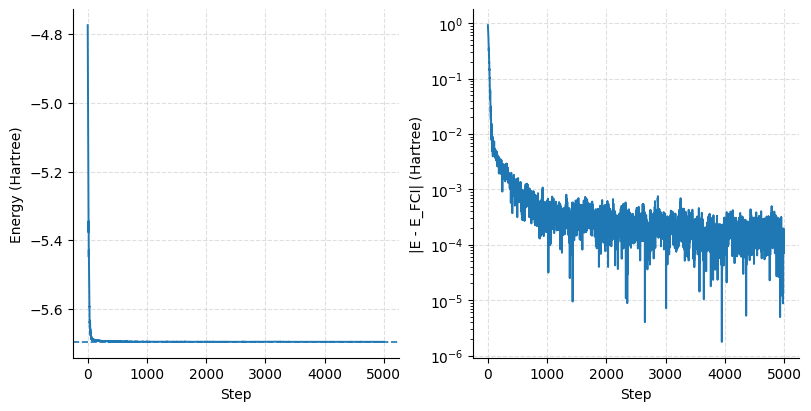

In [11]:
def plot_convergence(history, e_fci):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
    step = np.arange(len(history))

    ax = axes[0]
    ax.plot(step, history, linewidth=1.4)
    ax.axhline(e_fci, linestyle="--", linewidth=1.2)
    ax.set_xlabel("Step")
    ax.set_ylabel("Energy (Hartree)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    ax = axes[1]
    ax.semilogy(step, np.abs(np.asarray(history) - e_fci), linewidth=1.4)
    ax.set_xlabel("Step")
    ax.set_ylabel("|E - E_FCI| (Hartree)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    return fig, axes

plot_convergence(history, e_fci)
plt.show()